In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

RAS_list = ['HRAS', 'NRAS','KRAS4A', 'KRAS4B']
ras_dir = ['out_HRAS_DDAplus', 'out_NRAS_DDAplus', 'out_K4a_DDAplus','out_K4b_DDAplus3']
order= [['WT_LNTH', 'WT_HNTL', 'GD_HNTL','GD_LNTH'],
['WT_LNTH', 'WT_HNTL', 'GD_LNTH', 'GD_HNTL'],
['GD_HNTL', 'GD_LNTH', 'WT_HNTL', 'WT_LNTH'],
 ['GD_HNTL', 'GD_LNTH', 'WT_HNTL', 'WT_LNTH']] #H-N-Ka-Kb

def drop_zero_heavy_light(df):
    light = df.iloc[:, 1]
    heavy = df.iloc[:, 2]
    return df.loc[~((light == 0) & (heavy == 0)) & ~(light.isna() & heavy.isna()), :]
# Step 3: Add new column 'Median Ratios HL' by converting log2 ratios
def add_median_ratio(df):
    df['Median Ratios HL'] = 2 ** df.iloc[:, 6]  # Median Log2 Ratios HL is at 7th column (index 6)
    df['Median Ratios HL'] = df['Median Ratios HL'].clip(upper=100)  # cap it at 100
    return df

def count_selected(df_LNTH, df_HNTL):
    cond = (df_LNTH['Median Ratios HL'] > 1.5) & (df_HNTL['Median Ratios HL'] < 0.67)
    return cond.sum()

def venn_diagram(df_LNTH, df_HNTL, title):
    set_LNTH = set(df_LNTH.loc[df_LNTH['Median Ratios HL'] > 1.5, 'Entry Name'])
    set_HNTL = set(df_HNTL.loc[df_HNTL['Median Ratios HL'] < 0.67, 'Entry Name'])

    plt.figure(figsize=(6, 6))
    venn2([set_LNTH, set_HNTL], set_labels=('LNTH > 1.5', 'HNTL < 0.67'))
    plt.title(title)
    #plt.show()
    plt.savefig(title+'.png')

def adjust_median_ratios(df):
    heavy = df.iloc[:, 2]
    light = df.iloc[:, 1]
    modified = df[['Entry Name', 'Median Ratios HL']].copy()

    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    modified.loc[condition_heavy_only, 'Median Ratios HL'] = 100
    modified.loc[condition_light_only, 'Median Ratios HL'] = 0

    return modified


def count_selected_adj(df_LNTH, df_HNTL):
    cond = (df_LNTH['Median Ratios HL'] > 1.5) & (df_HNTL['Median Ratios HL'] < 0.67)
    return cond.sum()

def merge_forward_reverse(df_LNTH, df_HNTL):
    df_LNTH = df_LNTH.set_index('Entry Name')
    df_HNTL = df_HNTL.set_index('Entry Name')
    merged = pd.merge(df_LNTH, df_HNTL, how='inner', left_index=True, right_index=True, suffixes=('_Forward', '_Reverse'))
    merged = merged.sort_values('Median Ratios HL_Forward', ascending=False)
    return merged

def scatter_plot(df, title):
    df['Sample_Number'] = range(1, len(df) + 1)
    
    # Filter values greater than 2
    df_filtered = df[(df['Median Ratios HL_Forward'] > 2) ]

    plt.figure(figsize=(8, 6))
    plt.scatter(df_filtered['Sample_Number'], df_filtered['Median Ratios HL_Forward'], color='blue', label='Forward')
    plt.scatter(df_filtered['Sample_Number'], df_filtered['Median Ratios HL_Reverse'], color='red', label='Reverse')
    plt.xlabel('Protein number')
    plt.ylabel('Heavy/Light ratio')
    plt.title(title)
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.show()
    plt.savefig(title+'.png')

def add_LFQ_ratio(df):
    df['LFQ Ratios HL'] =round(df.iloc[:, 4]/df.iloc[:, 3],2) # light LFQ is at 4th column (index 3)
    df['LFQ Ratios HL'] = df['LFQ Ratios HL'].clip(upper=100)
    return df

def count_selected_LFQ(df_LNTH, df_HNTL):
    cond = (df_LNTH['LFQ Ratios HL'] > 1.5) & (df_HNTL['LFQ Ratios HL'] < 0.67)
    return cond.sum()

def venn_diagram_LFQ(df_LNTH, df_HNTL, title):
    set_LNTH = set(df_LNTH.loc[df_LNTH['LFQ Ratios HL'] > 1.5, 'Entry Name'])
    set_HNTL = set(df_HNTL.loc[df_HNTL['LFQ Ratios HL'] < 0.67, 'Entry Name'])

    plt.figure(figsize=(6, 6))
    venn2([set_LNTH, set_HNTL], set_labels=('LNTH > 1.5', 'HNTL < 0.67'))
    plt.title(title)
    #plt.show()
    plt.savefig(title+'.png')

def adjust_median_ratios_LFQ(df):
    heavy = df.iloc[:, 2]
    light = df.iloc[:, 1]
    modified = df[['Entry Name', 'LFQ Ratios HL']].copy()

    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    modified.loc[condition_heavy_only, 'LFQ Ratios HL'] = 100
    modified.loc[condition_light_only, 'LFQ Ratios HL'] = 0

    return modified

def merge_forward_reverse_LFQ(df_LNTH, df_HNTL):
    df_LNTH = df_LNTH.set_index('Entry Name')
    df_HNTL = df_HNTL.set_index('Entry Name')
    merged = pd.merge(df_LNTH, df_HNTL, how='inner', left_index=True, right_index=True, suffixes=('_Forward', '_Reverse'))
    merged = merged.sort_values('LFQ Ratios HL_Forward', ascending=False)
    return merged

def scatter_plot_LFQ(df, title):
    df['Sample_Number'] = range(1, len(df) + 1)
    df_filtered = df[(df['LFQ Ratios HL_Forward'] > 2) ]
    plt.figure(figsize=(8, 6))
    plt.scatter(df['Sample_Number'], df['LFQ Ratios HL_Forward'], color='blue', label='Forward')
    plt.scatter(df['Sample_Number'], df['LFQ Ratios HL_Reverse'], color='red', label='Reverse')
    plt.xlabel('Protein number')
    plt.ylabel('Heavy/Light ratio')
    plt.title(title)
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.show()
    plt.savefig(title+'.png')

def count_selected_adj_LFQ(df_LNTH, df_HNTL):
    cond = (df_LNTH['LFQ Ratios HL'] > 1.5) & (df_HNTL['LFQ Ratios HL'] < 0.67)
    return cond.sum()


def venn_diagram_WT_vs_G12D(WT_merged, G12D_merged, title):
    # Select only proteins satisfying condition
    WT_set = set(WT_merged.loc[(WT_merged['Median Ratios HL_Forward'] > 1.5) & (WT_merged['Median Ratios HL_Reverse'] < 0.67)].index)
    G12D_set = set(G12D_merged.loc[(G12D_merged['Median Ratios HL_Forward'] > 1.5) & (G12D_merged['Median Ratios HL_Reverse'] < 0.67)].index)

    plt.figure(figsize=(6, 6))
    venn2([WT_set, G12D_set], set_labels=('WT', 'G12D'))
    plt.title(title)
   # plt.show()
    plt.savefig(title+'.png')

def venn_diagram_WT_vs_G12D_LFQ(WT_merged, G12D_merged, title):
    # Select only proteins satisfying condition
    WT_set = set(WT_merged.loc[(WT_merged['LFQ Ratios HL_Forward'] > 1.5) & (WT_merged['LFQ Ratios HL_Reverse'] < 0.67)].index)
    G12D_set = set(G12D_merged.loc[(G12D_merged['LFQ Ratios HL_Forward'] > 1.5) & (G12D_merged['LFQ Ratios HL_Reverse'] < 0.67)].index)

    plt.figure(figsize=(6, 6))
    venn2([WT_set, G12D_set], set_labels=('WT', 'G12D'))
    plt.title(title)
   # plt.show()
    plt.savefig(title+'.png')

def count_forward_gt1p5_reverse_lt0p67(df_merged):
    condition = (df_merged['Median Ratios HL_Forward'] > 1.5) & (df_merged['Median Ratios HL_Reverse'] < 0.67)
    return condition.sum()

def count_forward_gt1p5_reverse_lt0p67_LFQ(df_merged):
    condition = (df_merged['LFQ Ratios HL_Forward'] > 1.5) & (df_merged['LFQ Ratios HL_Reverse'] < 0.67)
    return condition.sum()

import seaborn as sns

def bar_plot_counts(counts_dict, title):
    labels = list(counts_dict.keys())
    values = list(counts_dict.values())

    plt.figure(figsize=(8, 6))
    sns.barplot(x=labels, y=values)
    plt.ylabel('Number of Proteins')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
   # plt.show()

    plt.savefig(title+'_bar.png')

def venn_diagram_intersection(df1, df2, title):
    set1 = set(df1.loc[(df1['LFQ Ratios HL_Forward'] > 1.5) & (df1['LFQ Ratios HL_Reverse'] < 0.67)].index)
    set2 = set(df2.loc[(df2['LFQ Ratios HL_Forward'] > 1.5) & (df2['LFQ Ratios HL_Reverse'] < 0.67)].index)

    plt.figure(figsize=(6, 6))
    venn2([set1, set2], set_labels=('KRAS4a', 'KRAS4b'))
    plt.title(title)
   # plt.show()
    plt.savefig(title+'.png')

Processing HRAS...
HRAS Median - Original data:
WT selected proteins: 61
G12D selected proteins: 42
HRAS - Adjusted data:
WT selected proteins (adjusted): 150
G12D selected proteins (adjusted): 138


/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = 2 ** df.iloc[:, 6]  # Median Log2 Ratios HL is at 7th column (index 6)
/tmp/ipykernel_411244/2841629537.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = df['Median Ratios HL'].clip(upper=100)  # cap it at 100
/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

HRAS - LFQ Original data:
WT selected proteins: 45
G12D selected proteins: 26
HRAS - LFQ Adjusted data:
WT selected proteins (adjusted): 99
G12D selected proteins (adjusted): 106
Processing NRAS...
NRAS Median - Original data:
WT selected proteins: 153
G12D selected proteins: 44


/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = 2 ** df.iloc[:, 6]  # Median Log2 Ratios HL is at 7th column (index 6)
/tmp/ipykernel_411244/2841629537.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = df['Median Ratios HL'].clip(upper=100)  # cap it at 100
/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

NRAS - Adjusted data:
WT selected proteins (adjusted): 220
G12D selected proteins (adjusted): 133


...

NRAS - LFQ Original data:
WT selected proteins: 118
G12D selected proteins: 36
NRAS - LFQ Adjusted data:
WT selected proteins (adjusted): 150
G12D selected proteins (adjusted): 112
Processing KRAS4A...
KRAS4A Median - Original data:
WT selected proteins: 109
G12D selected proteins: 91
KRAS4A - Adjusted data:
WT selected proteins (adjusted): 134
G12D selected proteins (adjusted): 142


/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = 2 ** df.iloc[:, 6]  # Median Log2 Ratios HL is at 7th column (index 6)
/tmp/ipykernel_411244/2841629537.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = df['Median Ratios HL'].clip(upper=100)  # cap it at 100
/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

KRAS4A - LFQ Original data:
WT selected proteins: 83
G12D selected proteins: 64
KRAS4A - LFQ Adjusted data:
WT selected proteins (adjusted): 100
G12D selected proteins (adjusted): 105
Processing KRAS4B...
KRAS4B Median - Original data:
WT selected proteins: 47
G12D selected proteins: 36
KRAS4B - Adjusted data:
WT selected proteins (adjusted): 56
G12D selected proteins (adjusted): 56


/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = 2 ** df.iloc[:, 6]  # Median Log2 Ratios HL is at 7th column (index 6)
/tmp/ipykernel_411244/2841629537.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Median Ratios HL'] = df['Median Ratios HL'].clip(upper=100)  # cap it at 100
/tmp/ipykernel_411244/2841629537.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

KRAS4B - LFQ Original data:
WT selected proteins: 37
G12D selected proteins: 31
KRAS4B - LFQ Adjusted data:
WT selected proteins (adjusted): 42
G12D selected proteins (adjusted): 47


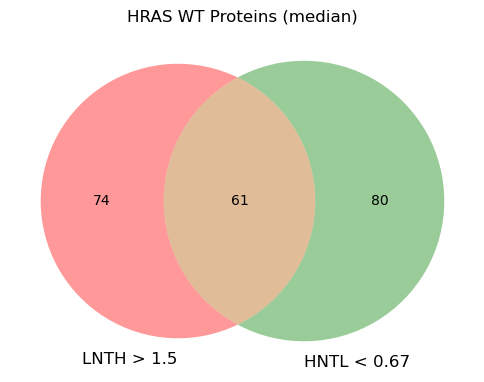

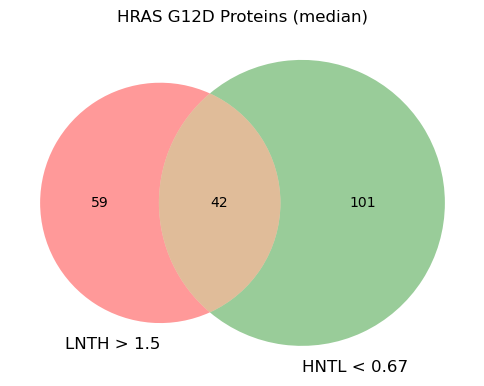

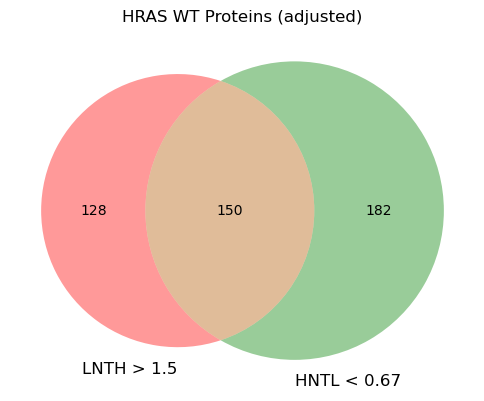

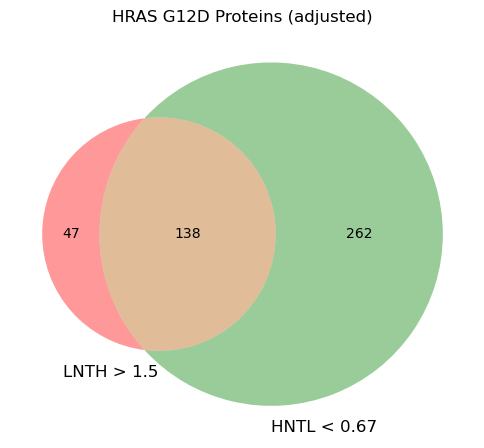

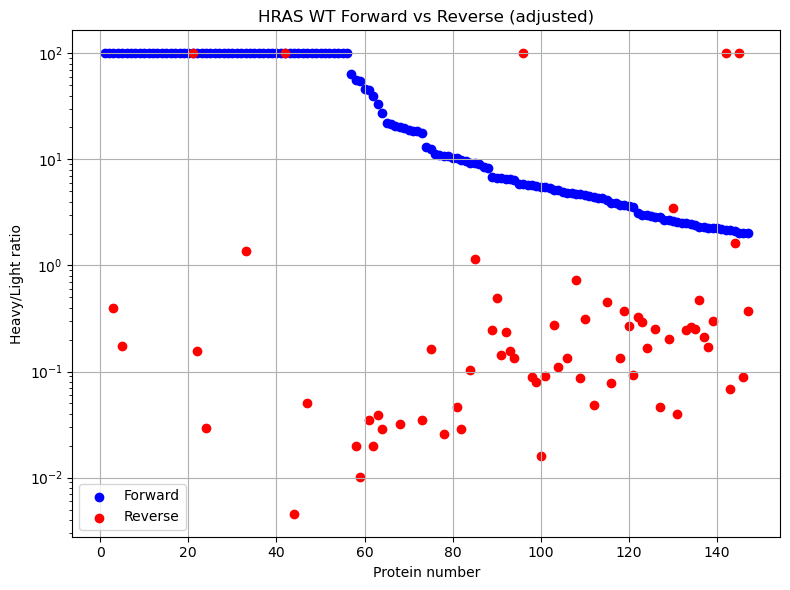

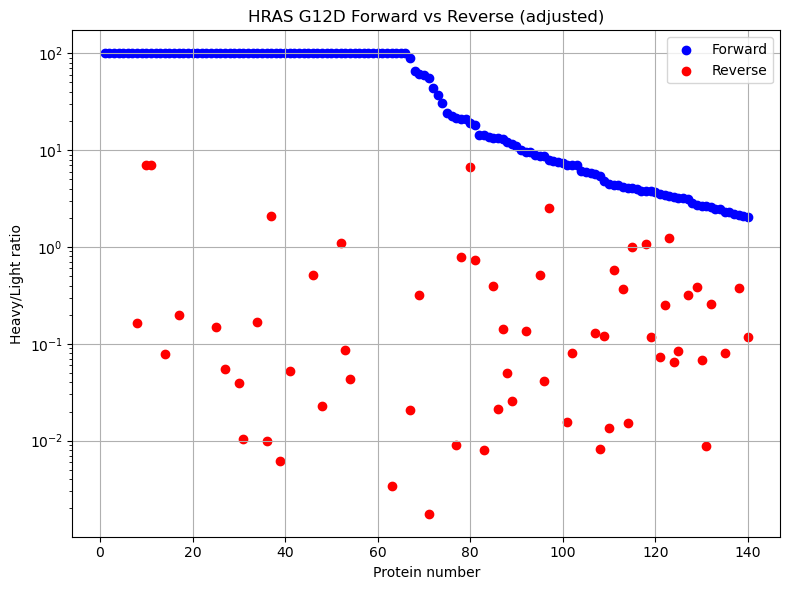

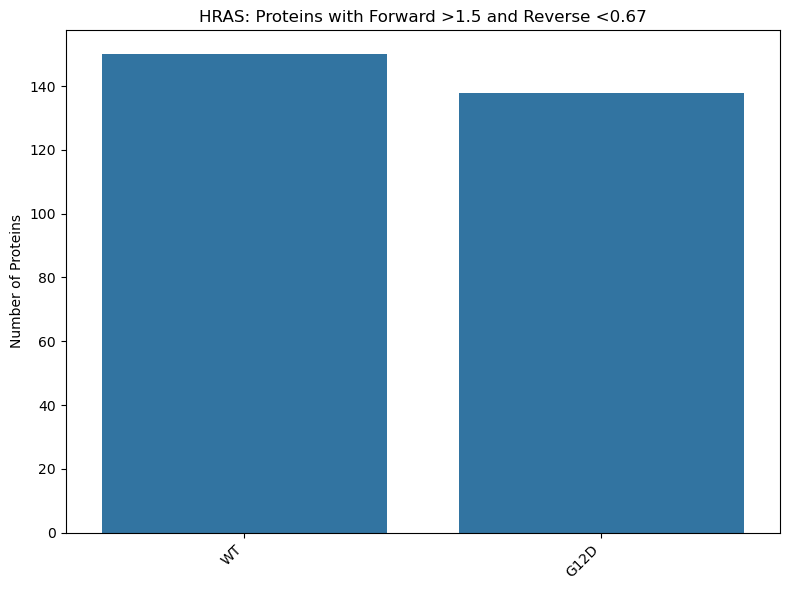

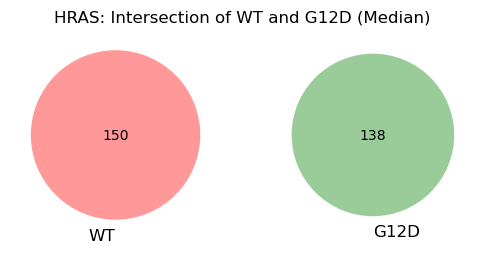

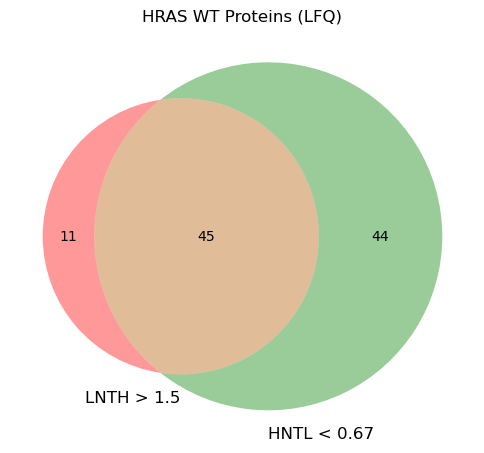

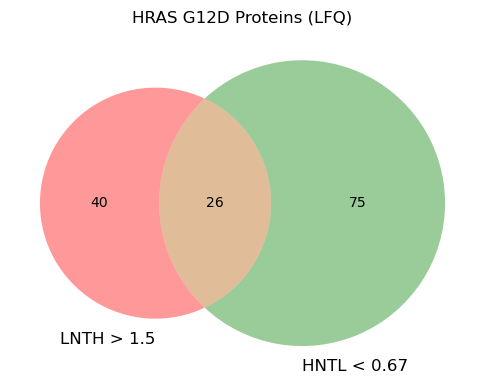

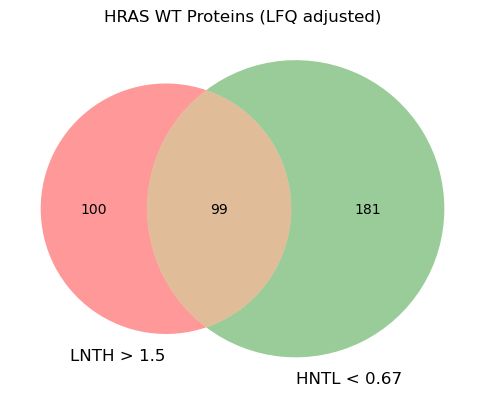

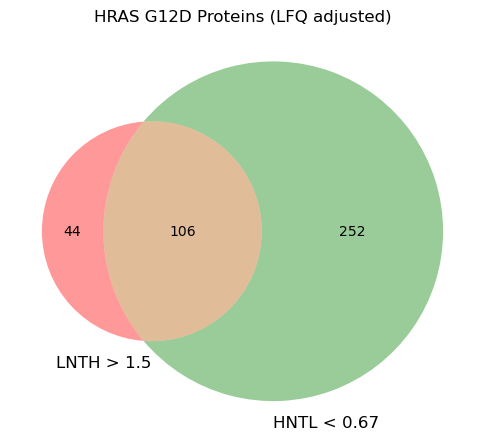

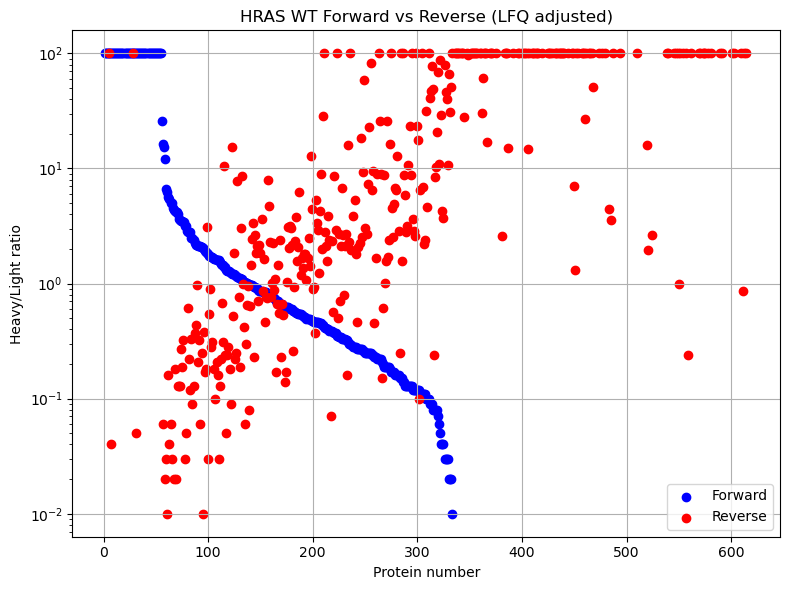

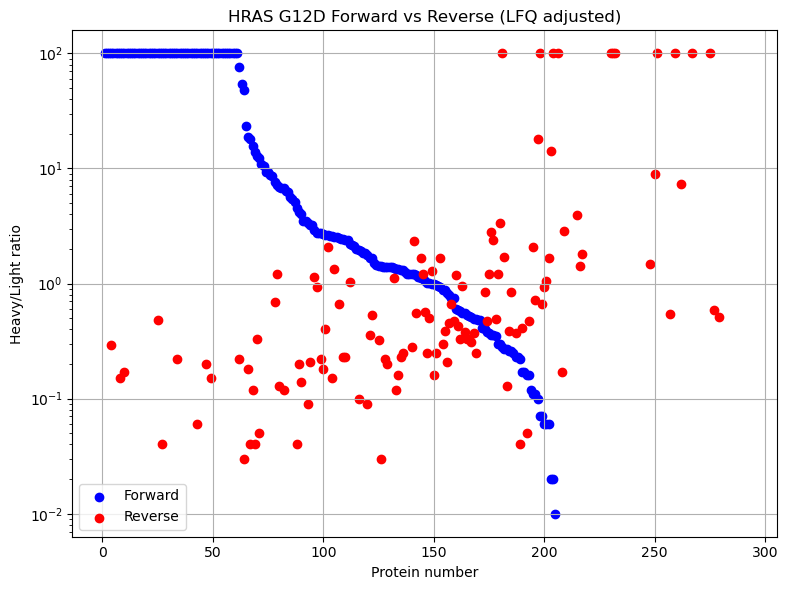

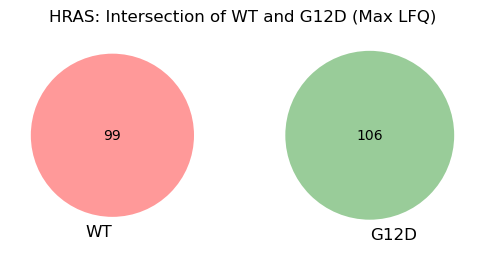

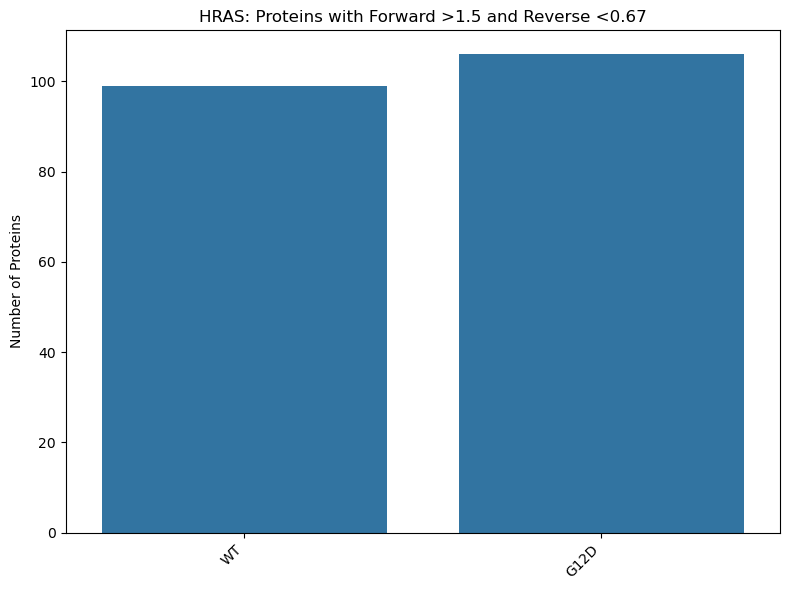

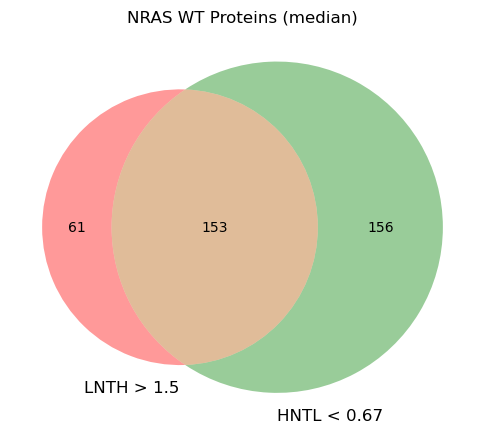

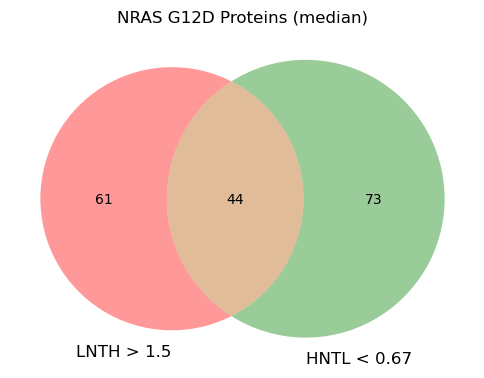

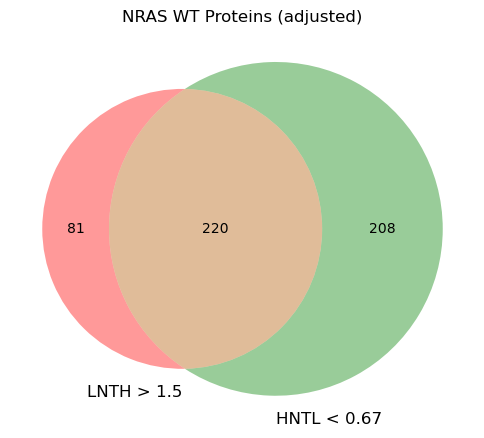

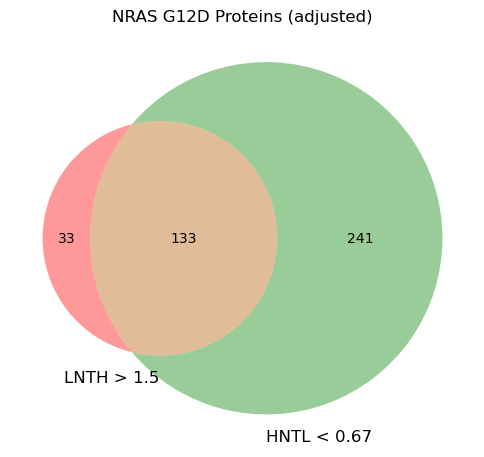

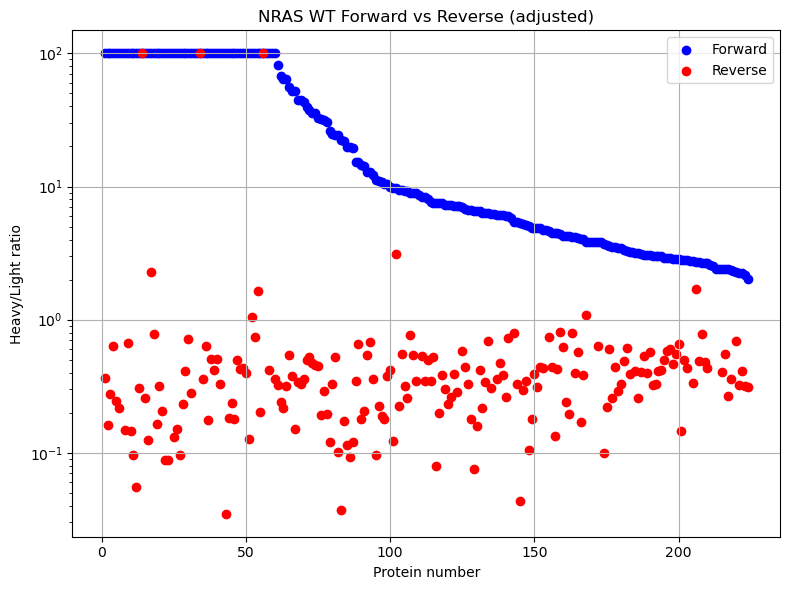

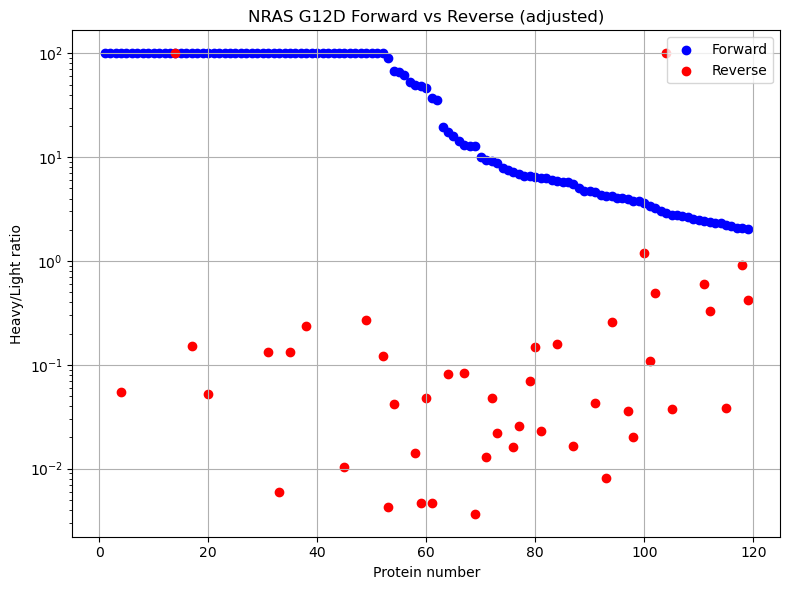

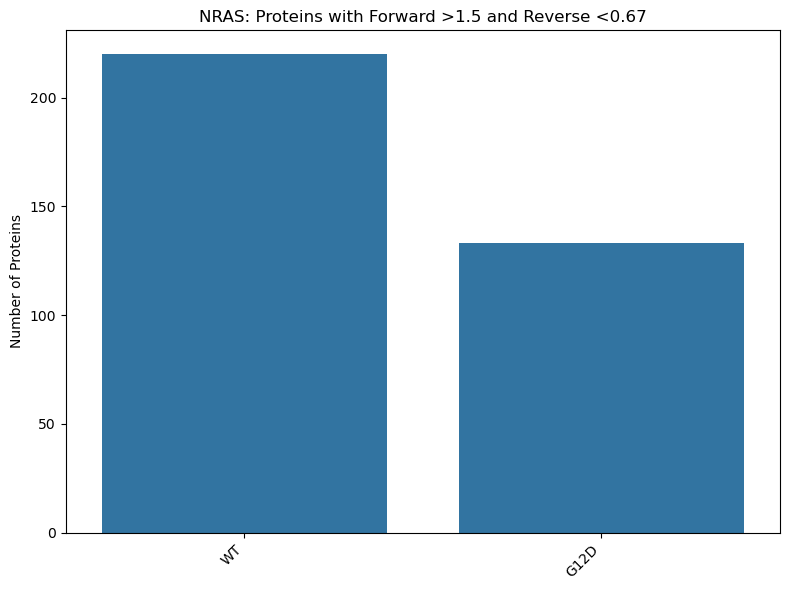

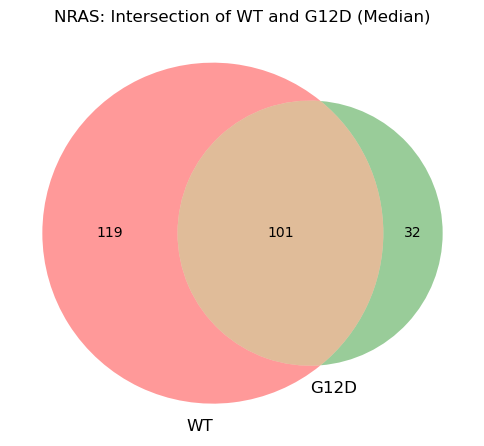

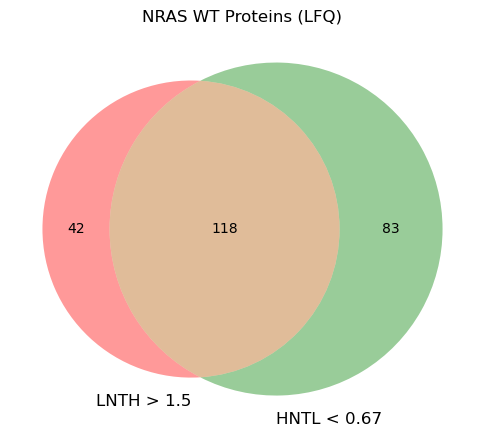

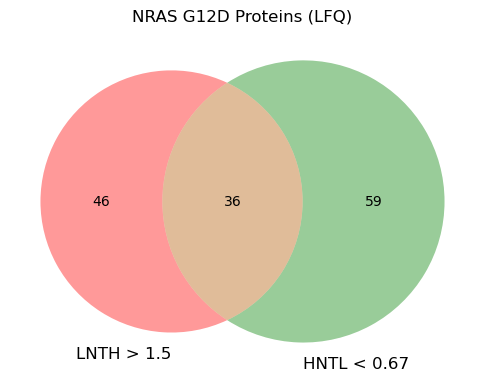

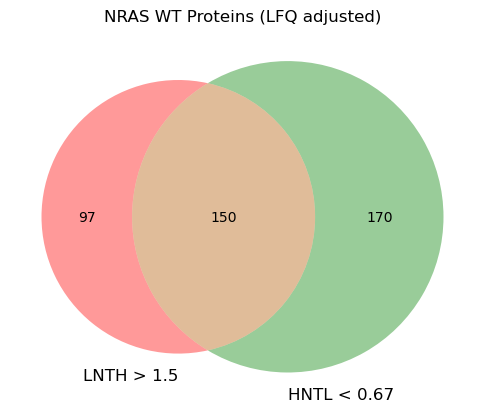

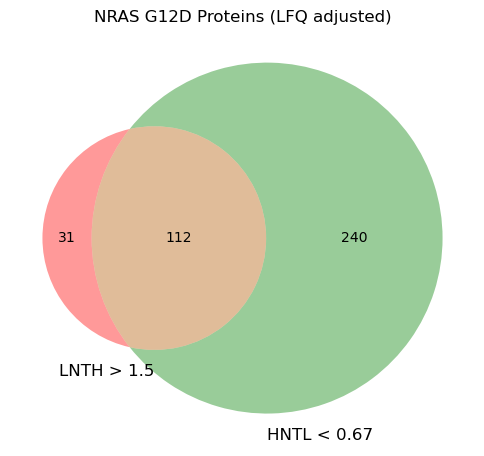

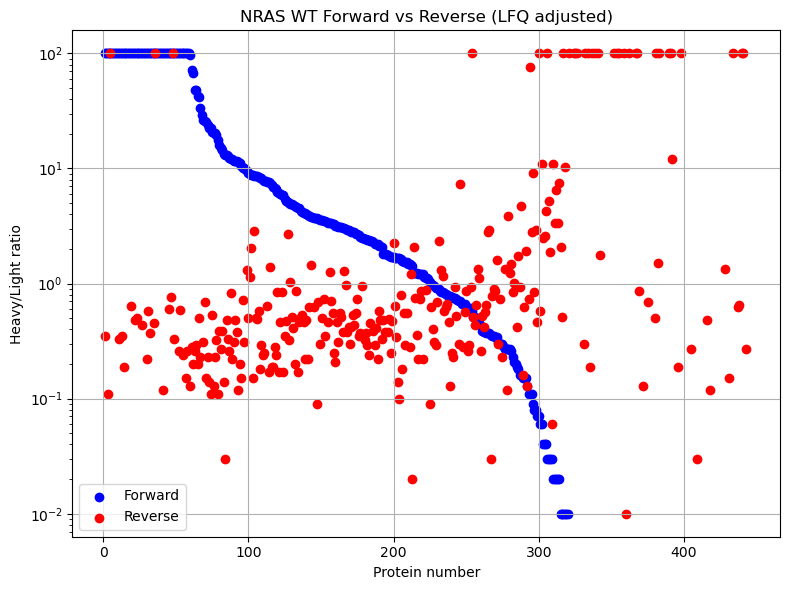

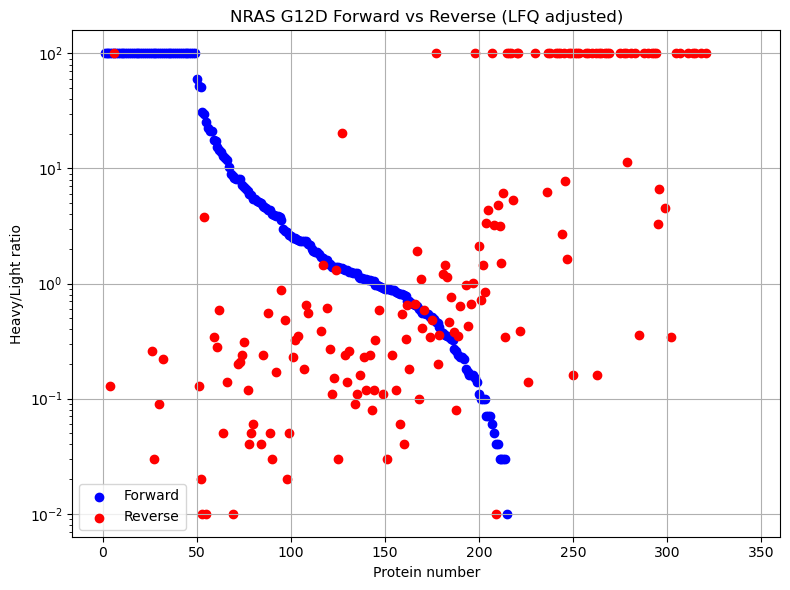

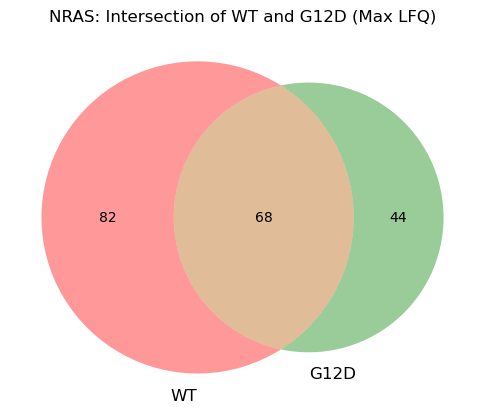

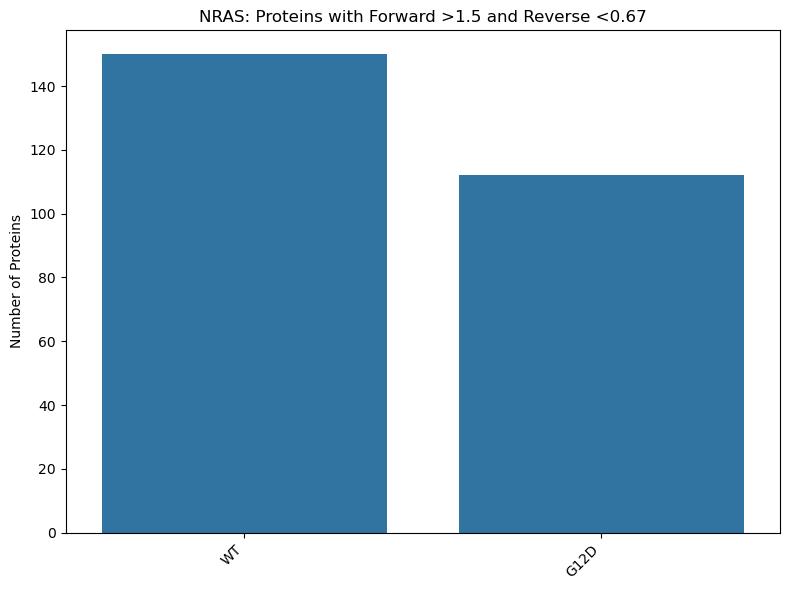

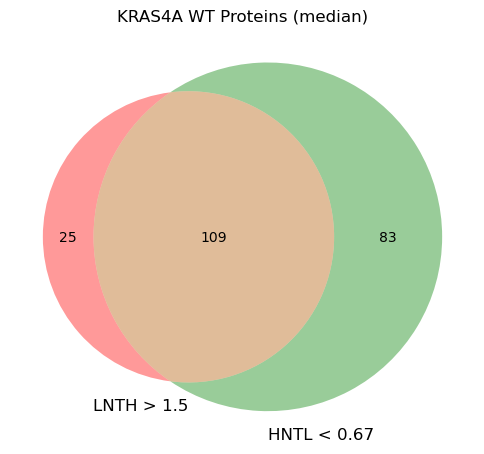

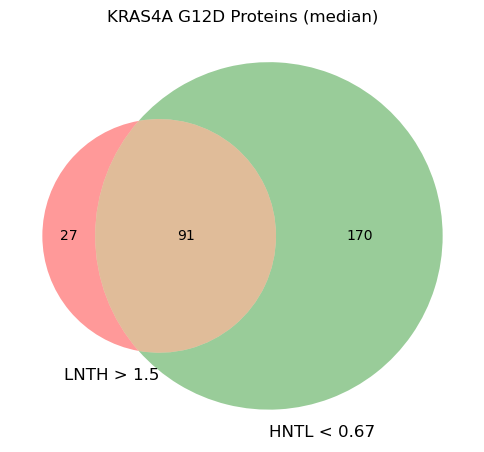

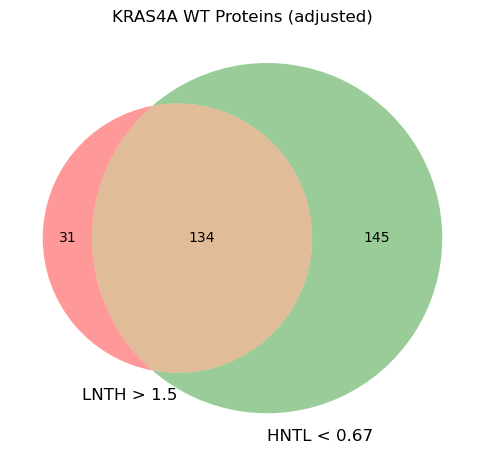

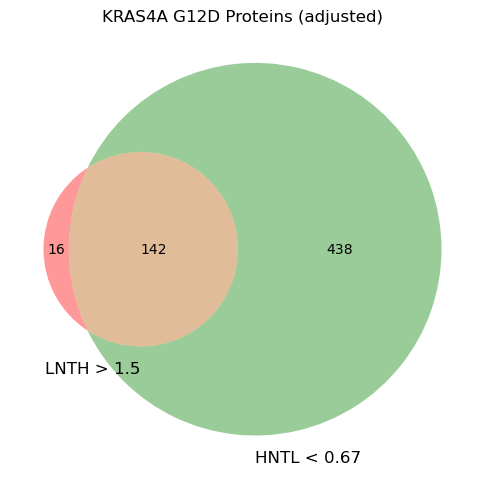

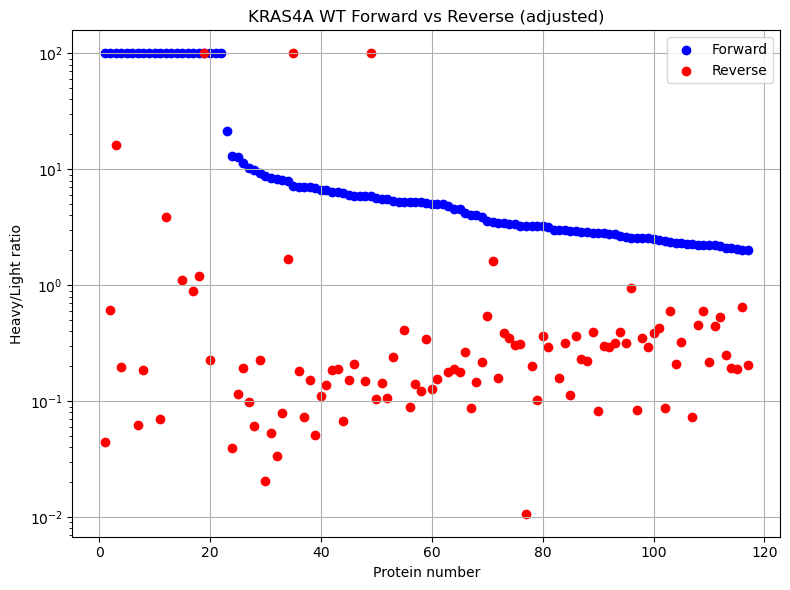

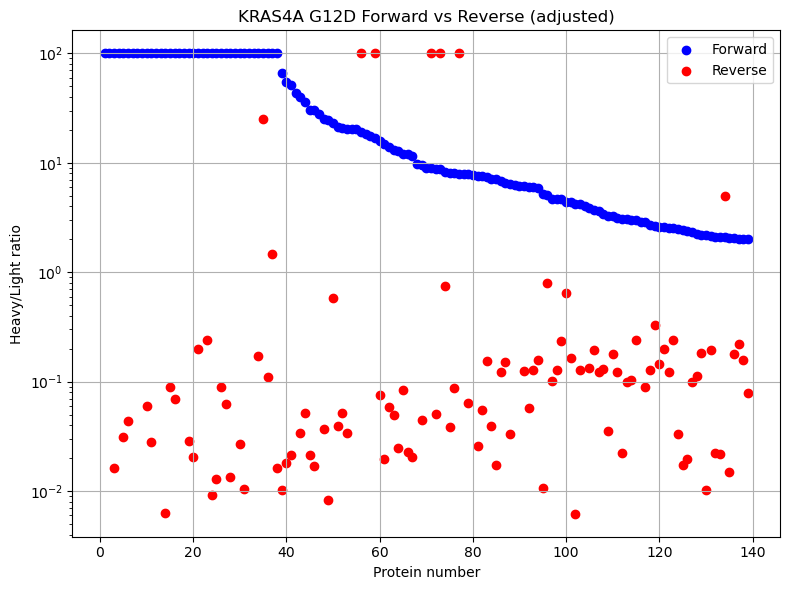

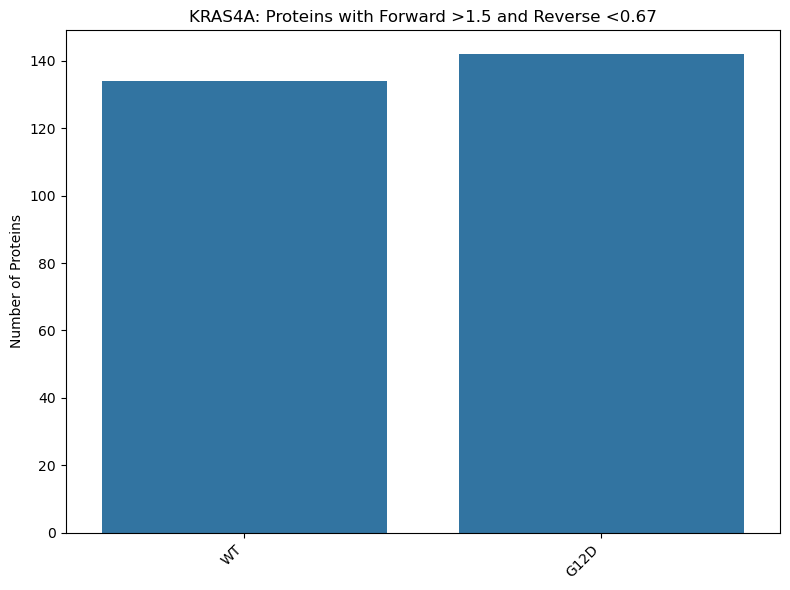

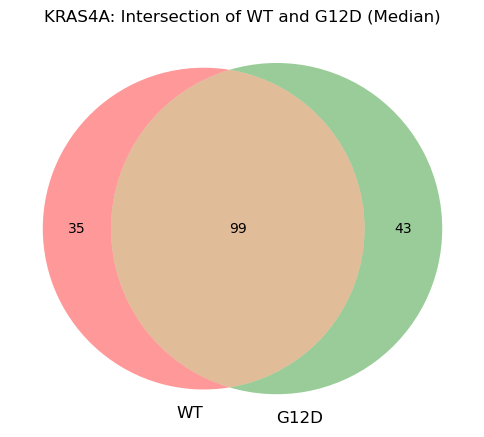

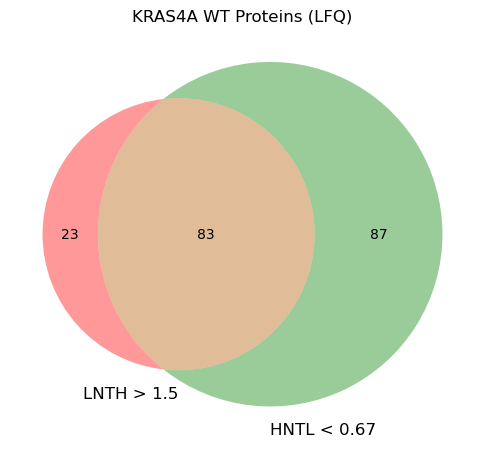

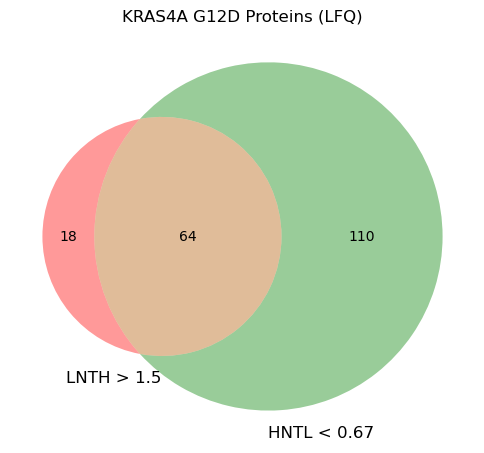

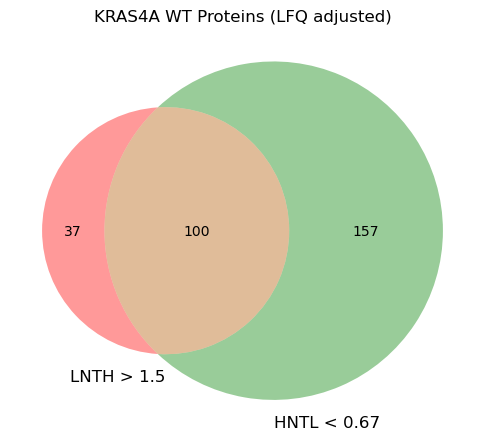

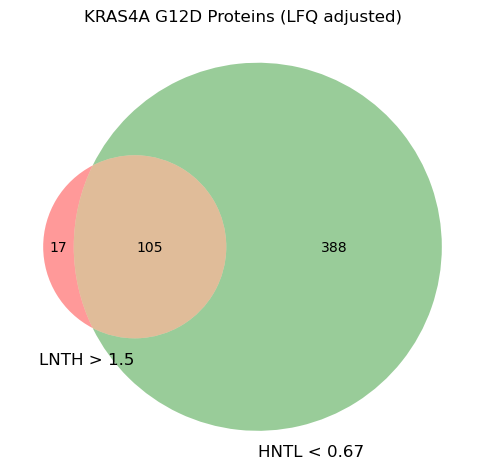

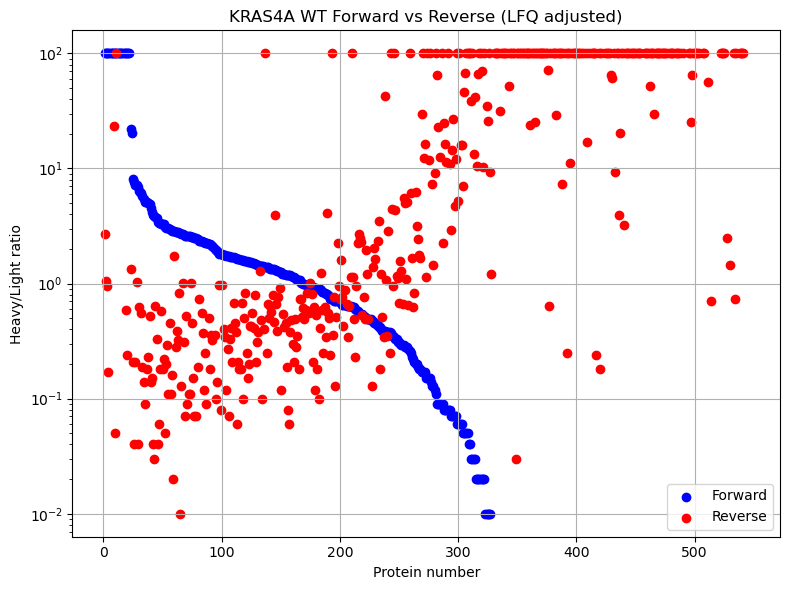

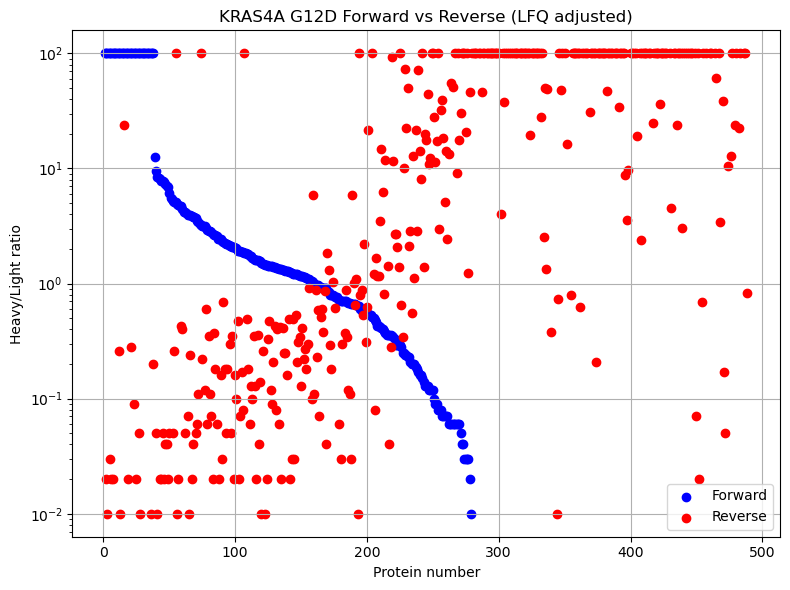

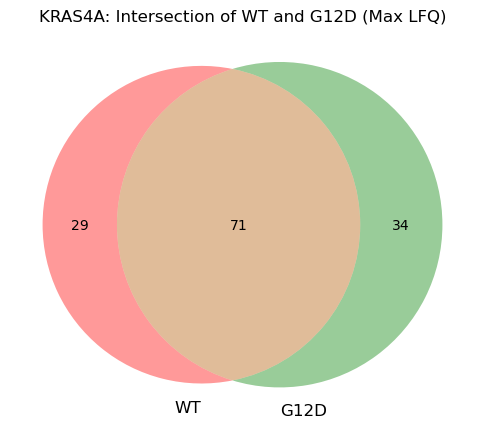

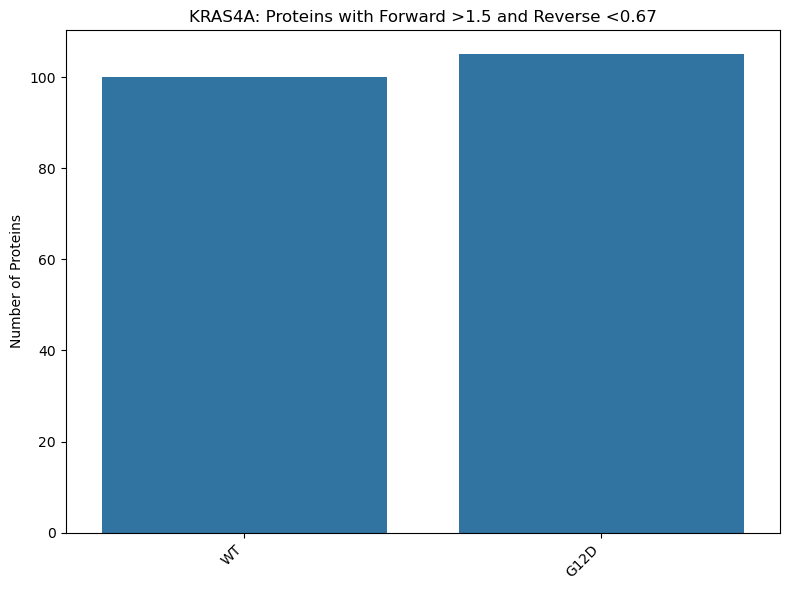

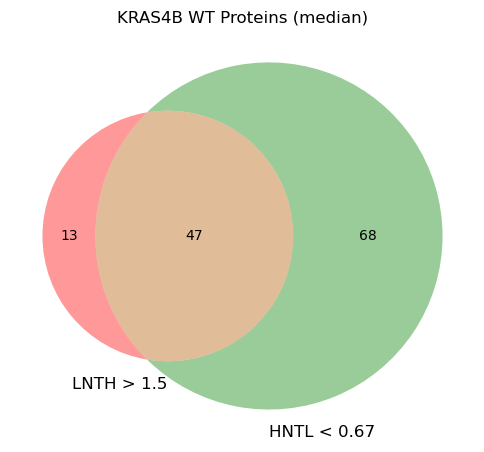

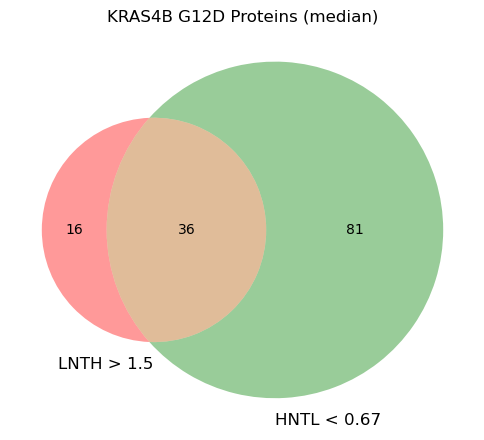

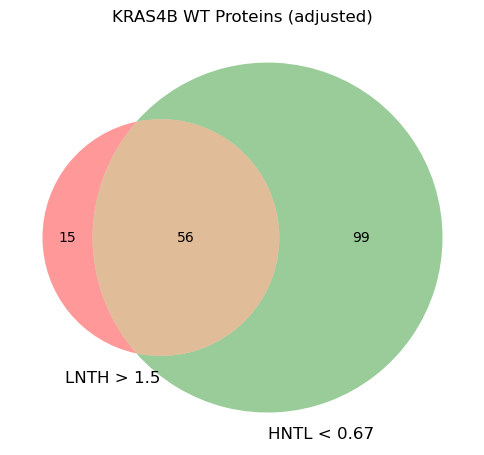

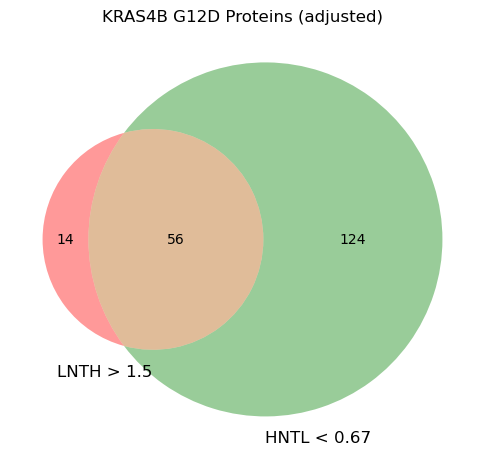

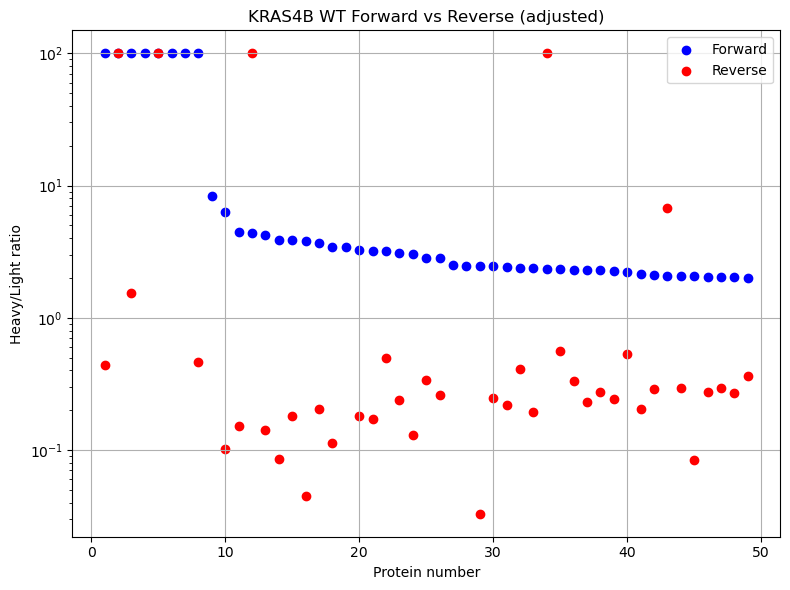

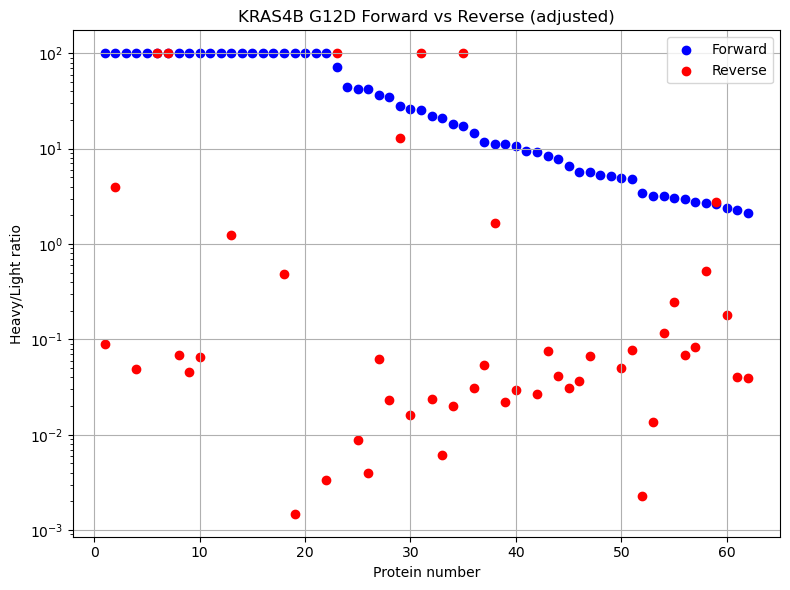

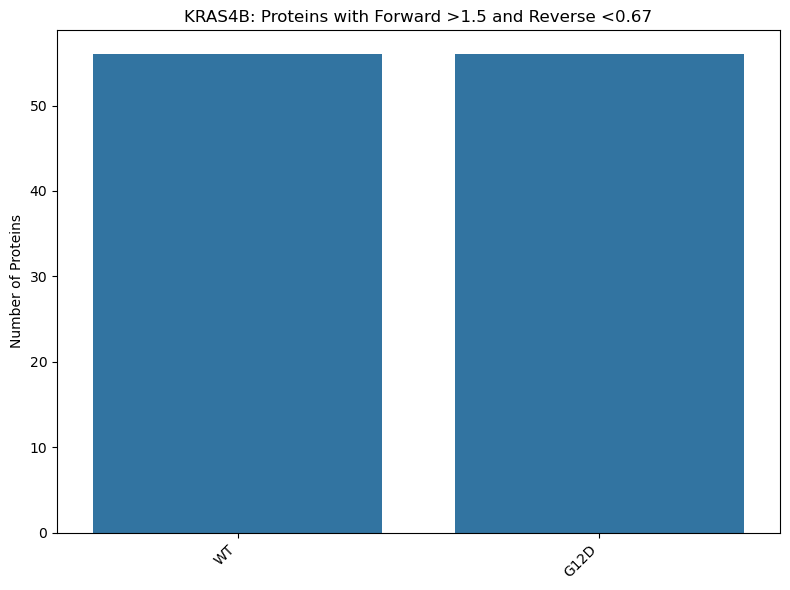

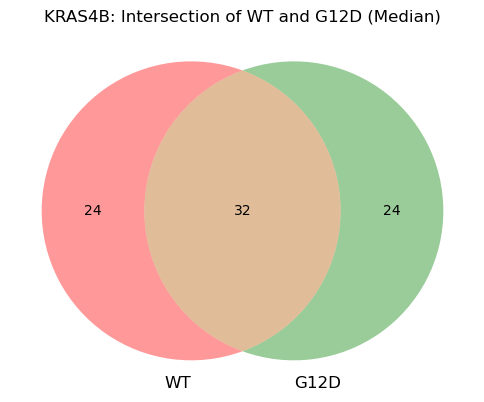

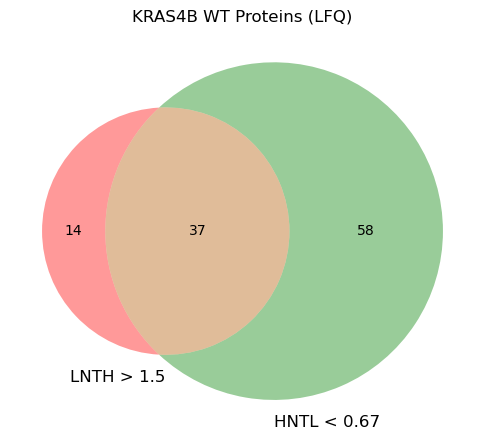

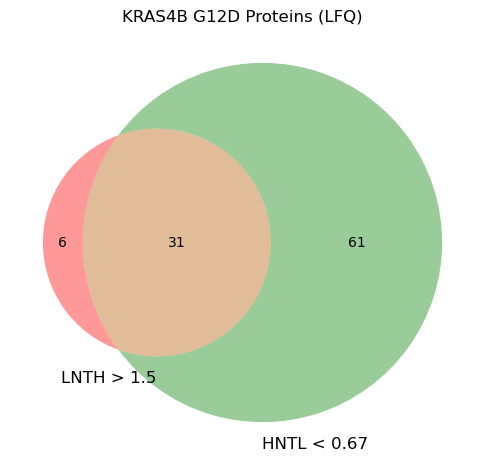

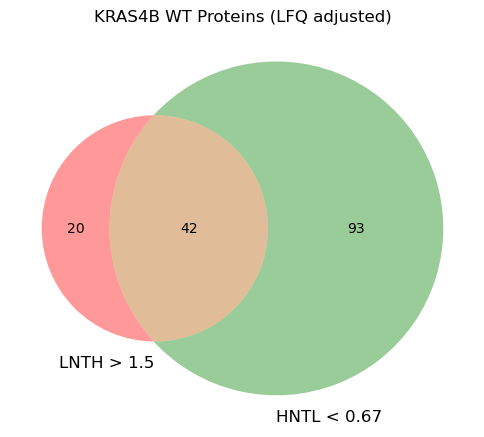

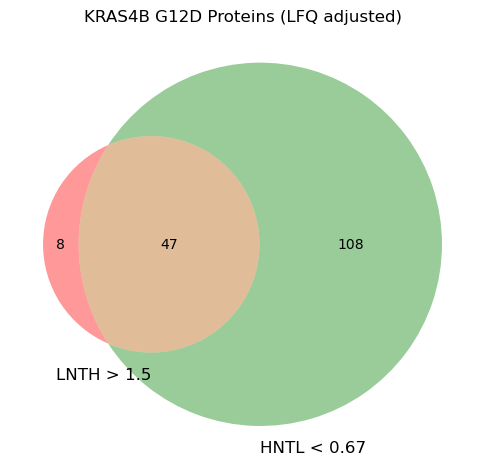

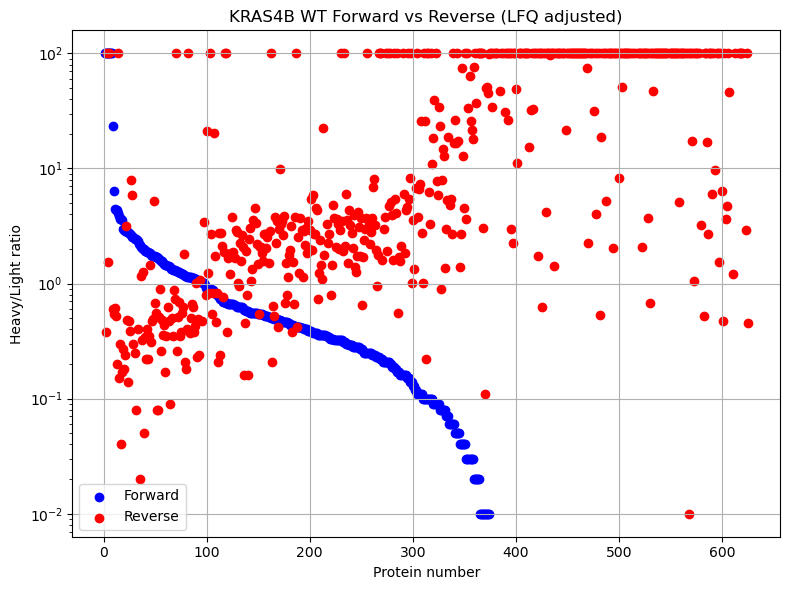

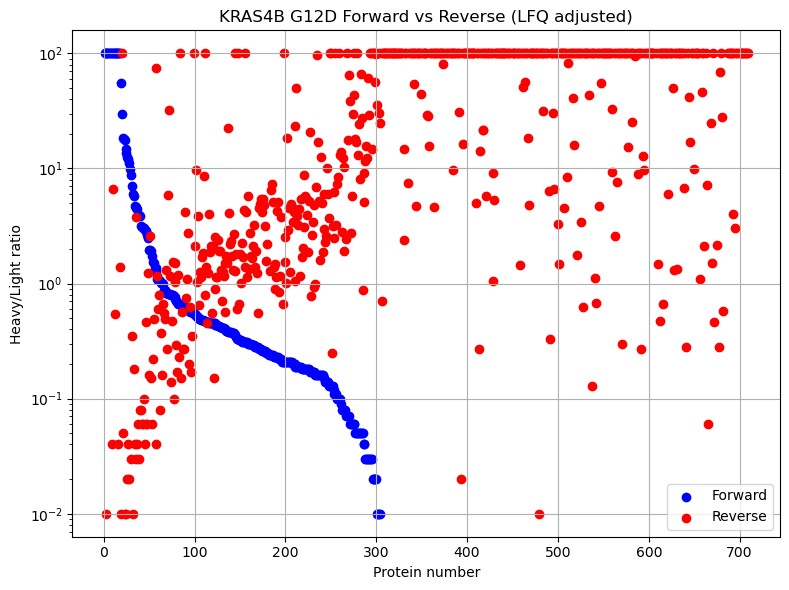

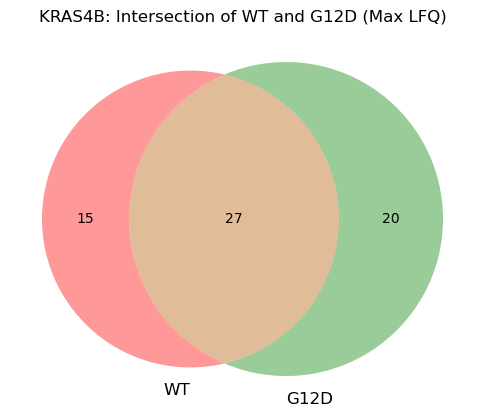

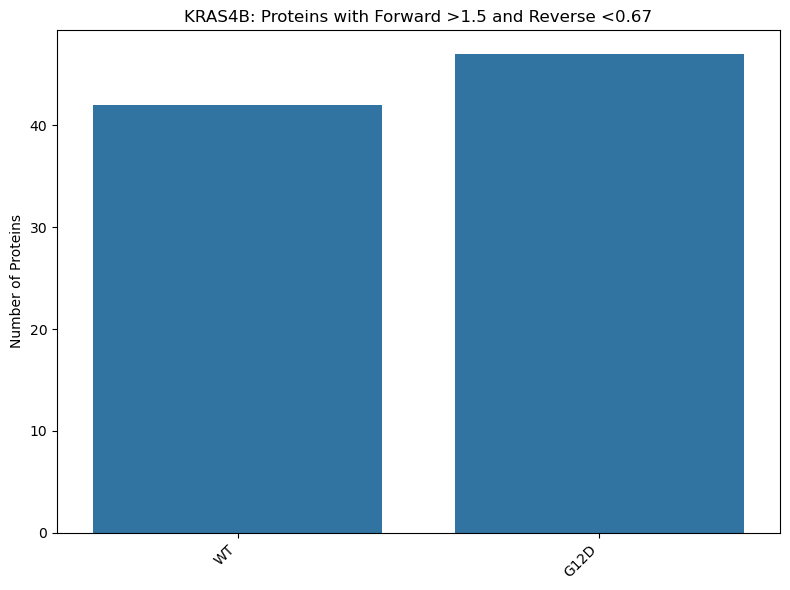

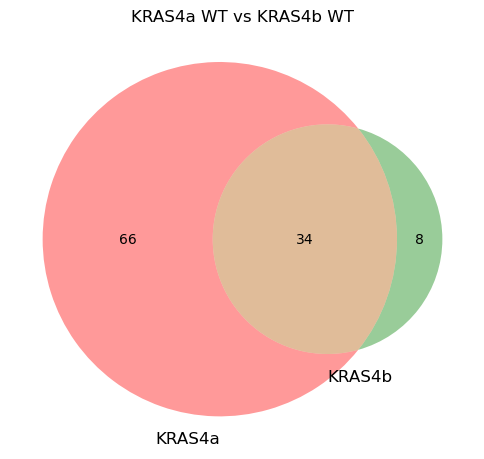

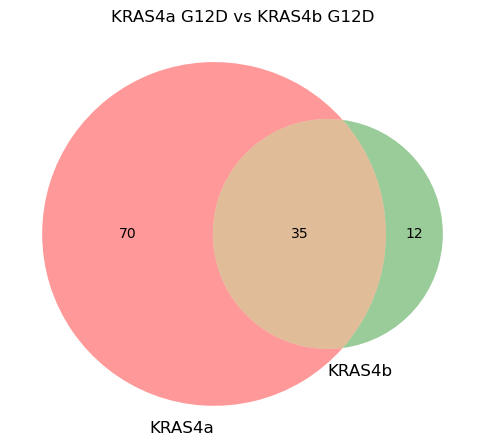

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Your constants
RAS_list = ['HRAS', 'NRAS', 'KRAS4A', 'KRAS4B']
ras_dir = ['out_HRAS_DDAplus', 'out_NRAS_DDAplus', 'out_K4a_DDAplus', 'out_K4b_DDAplus3']
order = [
    ['WT_LNTH', 'WT_HNTL', 'GD_HNTL', 'GD_LNTH'],  # HRAS
    ['WT_LNTH', 'WT_HNTL', 'GD_LNTH', 'GD_HNTL'],  # NRAS
    ['GD_HNTL', 'GD_LNTH', 'WT_HNTL', 'WT_LNTH'],  # KRAS4A
    ['GD_HNTL', 'GD_LNTH', 'WT_HNTL', 'WT_LNTH']   # KRAS4B
]

# Your functions (drop_zero_heavy_light, add_median_ratio, etc.) stay the same!
# I assume they are already defined.

# Loop through each RAS
for idx in range(len(RAS_list)):
    ras_name = RAS_list[idx]
    directory = ras_dir[idx]
    variable_order = order[idx]

    print(f"Processing {ras_name}...")

    # Load data
    tsv_dir = f"/media/seungyun/8TBHardDisk1/proteomics/OUT/{directory}/"
    RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

    # Split datasets based on order
    df_dict = {}
    for j, var_name in enumerate(variable_order):
        col_idx = [2, 5 + j, 9 + j, 13 + j, 17 + j, 21 + j, 25 + j]
        df_dict[var_name + '_raw'] = RAS.iloc[:, col_idx].copy()

    # Drop rows with zero light & heavy
    df_cleaned = {}
    for var in variable_order:
        df_cleaned[var] = drop_zero_heavy_light(df_dict[var + '_raw'])
        df_cleaned[var] = add_median_ratio(df_cleaned[var])

    # Assign cleaned datasets
    WT_LNTH = df_cleaned['WT_LNTH']
    WT_HNTL = df_cleaned['WT_HNTL']
    GD_LNTH = df_cleaned['GD_LNTH']
    GD_HNTL = df_cleaned['GD_HNTL']
    

    # Step 4: Print number of proteins satisfying condition
    print(f"{ras_name} Median - Original data:")
    print(f"WT selected proteins: {count_selected(WT_LNTH, WT_HNTL)}")
    print(f"G12D selected proteins: {count_selected(GD_LNTH, GD_HNTL)}")

    # Plot Venn diagrams
    venn_diagram(WT_LNTH, WT_HNTL, f"{ras_name} WT Proteins (median)")
    venn_diagram(GD_LNTH, GD_HNTL, f"{ras_name} G12D Proteins (median)")

    # Modify 'Median Ratios HL' for missing heavy/light
    WT_LNTH_adj = adjust_median_ratios(WT_LNTH)
    WT_HNTL_adj = adjust_median_ratios(WT_HNTL)
    GD_LNTH_adj = adjust_median_ratios(GD_LNTH)
    GD_HNTL_adj = adjust_median_ratios(GD_HNTL)

    # Step 6: Print adjusted results
    print(f"{ras_name} - Adjusted data:")
    print(f"WT selected proteins (adjusted): {count_selected_adj(WT_LNTH_adj, WT_HNTL_adj)}")
    print(f"G12D selected proteins (adjusted): {count_selected_adj(GD_LNTH_adj, GD_HNTL_adj)}")

    # Venn diagrams again after adjusting
    venn_diagram(WT_LNTH_adj, WT_HNTL_adj, f"{ras_name} WT Proteins (adjusted)")
    venn_diagram(GD_LNTH_adj, GD_HNTL_adj, f"{ras_name} G12D Proteins (adjusted)")

    # Merge Forward/Reverse and scatter plot
    WT_merged = merge_forward_reverse(WT_LNTH_adj, WT_HNTL_adj)
    GD_merged = merge_forward_reverse(GD_LNTH_adj, GD_HNTL_adj)
    scatter_plot(WT_merged, f"{ras_name} WT Forward vs Reverse (adjusted)")
    scatter_plot(GD_merged, f"{ras_name} G12D Forward vs Reverse (adjusted)")
   


    counts = {}
    counts['WT'] = count_forward_gt1p5_reverse_lt0p67(WT_merged)
    counts['G12D'] = count_forward_gt1p5_reverse_lt0p67(GD_merged)
    bar_plot_counts(counts, f"{RAS_list[idx]}: Proteins with Forward >1.5 and Reverse <0.67")

    venn_diagram_WT_vs_G12D(WT_merged, GD_merged, f"{ras_name}: Intersection of WT and G12D (Median)")


    # LFQ analysis
    for var in variable_order:
        df_cleaned[var] = add_LFQ_ratio(df_cleaned[var])

    WT_LNTH = df_cleaned['WT_LNTH']
    WT_HNTL = df_cleaned['WT_HNTL']
    GD_LNTH = df_cleaned['GD_LNTH']
    GD_HNTL = df_cleaned['GD_HNTL']

    print(f"{ras_name} - LFQ Original data:")
    print(f"WT selected proteins: {count_selected_LFQ(WT_LNTH, WT_HNTL)}")
    print(f"G12D selected proteins: {count_selected_LFQ(GD_LNTH, GD_HNTL)}")

    venn_diagram_LFQ(WT_LNTH, WT_HNTL, f"{ras_name} WT Proteins (LFQ)")
    venn_diagram_LFQ(GD_LNTH, GD_HNTL, f"{ras_name} G12D Proteins (LFQ)")

    # Adjust LFQ
    WT_LNTH_adj = adjust_median_ratios_LFQ(WT_LNTH)
    WT_HNTL_adj = adjust_median_ratios_LFQ(WT_HNTL)
    GD_LNTH_adj = adjust_median_ratios_LFQ(GD_LNTH)
    GD_HNTL_adj = adjust_median_ratios_LFQ(GD_HNTL)

    print(f"{ras_name} - LFQ Adjusted data:")
    print(f"WT selected proteins (adjusted): {count_selected_adj_LFQ(WT_LNTH_adj, WT_HNTL_adj)}")
    print(f"G12D selected proteins (adjusted): {count_selected_adj_LFQ(GD_LNTH_adj, GD_HNTL_adj)}")

    venn_diagram_LFQ(WT_LNTH_adj, WT_HNTL_adj, f"{ras_name} WT Proteins (LFQ adjusted)")
    venn_diagram_LFQ(GD_LNTH_adj, GD_HNTL_adj, f"{ras_name} G12D Proteins (LFQ adjusted)")

    # Merge and scatter LFQ
    WT_merged = merge_forward_reverse_LFQ(WT_LNTH_adj, WT_HNTL_adj)
    GD_merged = merge_forward_reverse_LFQ(GD_LNTH_adj, GD_HNTL_adj)
    WT_merged.to_csv(f"{ras_name} WT Proteins (LFQ adjusted).csv")
    GD_merged.to_csv(f"{ras_name} GD Proteins (LFQ adjusted).csv")

    scatter_plot_LFQ(WT_merged, f"{ras_name} WT Forward vs Reverse (LFQ adjusted)")
    scatter_plot_LFQ(GD_merged, f"{ras_name} G12D Forward vs Reverse (LFQ adjusted)")
    venn_diagram_WT_vs_G12D_LFQ(WT_merged, GD_merged, f"{ras_name}: Intersection of WT and G12D (Max LFQ)")
    
    # After you do WT_merged and G12D_merged

    # 1. Count proteins satisfying condition
    counts = {}
    counts['WT'] = count_forward_gt1p5_reverse_lt0p67_LFQ(WT_merged)
    counts['G12D'] = count_forward_gt1p5_reverse_lt0p67_LFQ(GD_merged)

    # 2. Barplot the numbers
    bar_plot_counts(counts, f"{RAS_list[idx]}: Proteins with Forward >1.5 and Reverse <0.67")

    # 3. Special case for KRAS4a and KRAS4b
    if RAS_list[idx] == 'KRAS4A':
        KRAS4a_WT_merged = WT_merged.copy()
        KRAS4a_G12D_merged = GD_merged.copy()

    if RAS_list[idx] == 'KRAS4B':
        KRAS4b_WT_merged = WT_merged.copy()
        KRAS4b_G12D_merged = GD_merged.copy()

# AFTER loop finishes
venn_diagram_intersection(KRAS4a_WT_merged, KRAS4b_WT_merged, "KRAS4a WT vs KRAS4b WT")
venn_diagram_intersection(KRAS4a_G12D_merged, KRAS4b_G12D_merged, "KRAS4a G12D vs KRAS4b G12D")
